# Dataset Creation

In [ ]:
!pip install fathomnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 21.7 MB/s eta 0:00:00


In [ ]:
import os
import requests
import random  # Added for shuffling
from io import BytesIO
from PIL import Image
from fathomnet.api import images


DATASET_DIR = 'fathomnet_classification'
IMAGE_SIZE = (224, 224)
MAX_IMAGES_PER_CONCEPT = 500

def create_dataset(concepts):
    for concept in concepts:
        print(f"--- Processing concept: {concept} ---")
        save_path = os.path.join(DATASET_DIR, concept.replace(" ", "_"))
        os.makedirs(save_path, exist_ok=True)

        # 1. Fetch all available records
        all_records = images.find_by_concept(concept)

        # 2. Shuffle the records list in-place for randomness
        random.shuffle(all_records)

        print(f"Found {len(all_records)} total records. Target: {MAX_IMAGES_PER_CONCEPT}")

        count = 0
        for r in all_records:
            if count >= MAX_IMAGES_PER_CONCEPT:
                break

            try:
                resp = requests.get(r.url, timeout=15)
                if resp.status_code != 200:
                    continue

                with Image.open(BytesIO(resp.content)) as full_img:
                    full_img = full_img.convert('RGB')
                    img_w, img_h = full_img.size

                    for b_idx, bbox in enumerate(r.boundingBoxes):
                        if count >= MAX_IMAGES_PER_CONCEPT:
                            break

                        if bbox.concept == concept:
                            # Boundary validation
                            left = max(0, int(bbox.x))
                            top = max(0, int(bbox.y))
                            right = min(img_w, int(left + bbox.width))
                            bottom = min(img_h, int(top + bbox.height))

                            if right <= left or bottom <= top:
                                continue

                            # Crop and save
                            crop = full_img.crop((left, top, right, bottom))
                            if IMAGE_SIZE:
                                crop = crop.resize(IMAGE_SIZE, Image.Resampling.LANCZOS)

                            crop_filename = f"{r.uuid}_{b_idx}.jpg"
                            crop.save(os.path.join(save_path, crop_filename), "JPEG", quality=95)

                            count += 1

            except Exception as e:
                print(f"Error processing {getattr(r, 'uuid', 'unknown')}: {e}")

        print(f"Done. Collected {count} random samples for {concept}.")



In [ ]:
from fathomnet.api import boundingboxes

print("Fetching global concept counts from FathomNet...")

all_counts = boundingboxes.count_total_by_concept()

all_counts.sort(key=lambda x: x.count, reverse=True)

exclude_list = [
    "equipment", "unknown", "marine organism", "particulate",
    "trash", "debris", "rov", "animalia", "ocean floor", "background"
]

concepts = []

print("\n========Top 10 Most Populated Marine Species=========")
for item in all_counts:
    if item.concept.lower() not in exclude_list:
        concepts.append(item.concept)
        print(f"{len(concepts)}. {item.concept} (Annotations: {item.count})")
    if len(concepts) == 10:
        break

Fetching global concept counts from FathomNet...

========Top 10 Most Populated Marine Species=========
1. Lutjanus campechanus (Annotations: 151292)
2. sea fan (Annotations: 51480)
3. Stenotomus caprinus (Annotations: 26775)
4. Rhomboplites aurorubens (Annotations: 25825)
5. Strongylocentrotus fragilis (Annotations: 23061)
6. bony fish (Annotations: 21664)
7. Ptereleotris (Annotations: 21131)
8. sponge (Annotations: 21107)
9. Pagrus pagrus (Annotations: 17028)
10. Chromis (Annotations: 15769)


In [ ]:
create_dataset(concepts)

--- Processing concept: Lutjanus campechanus ---
Found 67543 total records. Target: 500
Done. Collected 500 random samples for Lutjanus campechanus.
--- Processing concept: sea fan ---
Found 37486 total records. Target: 500
Done. Collected 500 random samples for sea fan.
--- Processing concept: Stenotomus caprinus ---
Found 10468 total records. Target: 500
Done. Collected 500 random samples for Stenotomus caprinus.
--- Processing concept: Rhomboplites aurorubens ---
Found 10153 total records. Target: 500
Done. Collected 500 random samples for Rhomboplites aurorubens.
--- Processing concept: Strongylocentrotus fragilis ---
Found 4600 total records. Target: 500
Done. Collected 500 random samples for Strongylocentrotus fragilis.
--- Processing concept: bony fish ---
Found 14384 total records. Target: 500
Done. Collected 500 random samples for bony fish.
--- Processing concept: Ptereleotris ---
Found 7821 total records. Target: 500
Done. Collected 500 random samples for Ptereleotris.
--- P

# Helper Functions

In [ ]:
import os
import random
import time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / len(loader.dataset), all_preds, all_labels

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import torch
import torch.nn.functional as F
import numpy as np

def evaluate_ood_detection(model, val_loader, ood_loader, threshold=0.7,temp=1):
    model.eval()
    y_true, y_pred = [], []
    T = temp

    with torch.no_grad():
        # ID (known) samples
        for images, _ in val_loader:
            images = images.to(DEVICE)
            outputs = model(images)/T
            probs = F.softmax(outputs, dim=1)
            max_probs, _ = torch.max(probs, dim=1)
            preds = (max_probs < threshold).cpu().numpy().astype(int)
            y_pred.extend(preds)
            y_true.extend([0]*len(preds))
        # OOD (unknown) samples
        for images, _ in ood_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            outputs = outputs / T  # Scale logits before Softmax
            probs = F.softmax(outputs, dim=1)
            max_probs, _ = torch.max(probs, dim=1)
            preds = (max_probs > threshold).cpu().numpy().astype(int)
            y_pred.extend(preds)
            y_true.extend([1]*len(preds))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(y_true, y_pred, target_names=['Known (ID)', 'Unknown (OOD)'], digits=3, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return report, cm, acc, f1

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_experiment_full(train_losses, val_losses, train_accs, val_accs,
                              report, macro_f1, accuracy, cm, class_names, title_suffix=""):
    epochs = len(train_losses)
    epochs_range = range(1, epochs + 1)

    # -------------------------------
    # 1. Loss & Accuracy Curves
    # -------------------------------
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve - {title_suffix}')
    plt.legend()
    plt.grid(True)
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, label='Train Acc')
    plt.plot(epochs_range, val_accs, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Curve - {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # -------------------------------
    # 2. Confusion Matrix
    # -------------------------------
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {title_suffix}")
    plt.show()

    # -------------------------------
    # 3. Per-class metrics
    # -------------------------------
    print(f"Per-class metrics - {title_suffix}:")
    for cls in class_names:
        metrics = report.get(cls, {'precision':0, 'recall':0, 'f1-score':0})
        print(f"{cls}: Precision={metrics['precision']:.3f}, Recall={metrics['recall']:.3f}, F1={metrics['f1-score']:.3f}")
    print(f"\nMacro F1 ({title_suffix}): {macro_f1:.3f}")
    print(f"Overall Accuracy ({title_suffix}): {accuracy:.3f}")

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def suggest_ood_threshold(model, val_loader, ood_loader, device='cuda', plot=True, target_tpr=0.95,temp=1):
    model.eval()
    id_probs, ood_probs = [], []
    T=temp
    with torch.no_grad():
        # ID samples
        for x, _ in val_loader:
            x = x.to(device)
            probs = F.softmax(model(x)/T, dim=1)
            id_probs.extend(probs.max(dim=1)[0].cpu().numpy())
        # OOD samples
        for x, _ in ood_loader:
            x = x.to(device)
            probs = F.softmax(model(x)/T, dim=1)
            ood_probs.extend(probs.max(dim=1)[0].cpu().numpy())

    labels = np.array([0]*len(id_probs) + [1]*len(ood_probs))
    scores = np.array(id_probs + ood_probs)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    # Pick threshold for target TPR
    idx = np.argmax(tpr >= target_tpr)
    suggested_threshold = thresholds[idx]
    threshold_fpr = fpr[idx]

    print(f"Suggested OOD threshold for TPR={target_tpr*100:.0f}%: {suggested_threshold:.3f}")
    print(f"FPR at this threshold: {threshold_fpr:.3f}")
    print(f"AUROC: {roc_auc:.3f}")

    # Optional plot
    if plot:
        plt.figure(figsize=(8,5))
        plt.hist(id_probs, bins=50, alpha=0.6, label='ID', color='green', density=True)
        plt.hist(ood_probs, bins=50, alpha=0.6, label='OOD', color='red', density=True)
        plt.axvline(suggested_threshold, color='blue', linestyle='--', label=f'Suggested Threshold: {suggested_threshold:.2f}')
        plt.xlabel("Maximum Softmax Probability")
        plt.ylabel("Density")
        plt.title("ID vs OOD MSP Distribution")
        plt.legend()
        plt.show()

    return suggested_threshold

# Preprocessing

In [ ]:
DATA_DIR = Path('fathomnet_classification')
BATCH_SIZE = 64
IMG_SIZE = 224
NUM_EPOCHS = 10
NUM_CLASSES = 8

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, random_split
from sklearn.metrics import precision_score, recall_score
import os
# 1. Define Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


# 2. Load full dataset
def valid_file(path):
    return not any(part.startswith('.') for part in path.split(os.sep))

full_dataset = ImageFolder(
    DATA_DIR,
    transform=train_transforms,
    is_valid_file=valid_file
)

class_names = full_dataset.classes
print('All classes:', class_names)

# 3. Identify ID and OOD classes
NUM_CLASSES = len(class_names) - 2        # ID classes count
OOD_CLASSES = class_names[-2:]            # last 2 classes are OOD
ID_CLASSES = class_names[:NUM_CLASSES]    # known classes

print("ID classes:", ID_CLASSES)
print("OOD classes:", OOD_CLASSES)

# 4. Create subsets
id_indices = [i for i, (_, label) in enumerate(full_dataset) if label < NUM_CLASSES]
ood_indices = [i for i, (_, label) in enumerate(full_dataset) if label >= NUM_CLASSES]

id_dataset = Subset(full_dataset, id_indices)
ood_dataset = Subset(full_dataset, ood_indices)


# 5. Split ID dataset into train/val/test
train_size = int(0.7 * len(id_dataset))
val_size = int(0.15 * len(id_dataset))
test_size = len(id_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    id_dataset, [train_size, val_size, test_size]
)

# Set proper transforms
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

# 6. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
ood_loader = DataLoader(ood_dataset, batch_size=BATCH_SIZE)


All classes: ['Chromis', 'Lutjanus_campechanus', 'Pagrus_pagrus', 'Ptereleotris', 'Rhomboplites_aurorubens', 'Stenotomus_caprinus', 'Strongylocentrotus_fragilis', 'bony_fish', 'sea_fan', 'sponge']
ID classes: ['Chromis', 'Lutjanus_campechanus', 'Pagrus_pagrus', 'Ptereleotris', 'Rhomboplites_aurorubens', 'Stenotomus_caprinus', 'Strongylocentrotus_fragilis', 'bony_fish']
OOD classes: ['sea_fan', 'sponge']


In [ ]:
id_classes = concepts[:8]
ood_classes = concepts[8:]  # last 2 elements
class_names_full = id_classes + ['Unknown (OOD)']  # Combine for visualization

# Model A

In [ ]:
import torch
import torch.nn as nn

class ScratchCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

def run_experiment(num_classes, class_names, train_loader, val_loader,
                   lr=1e-3, epochs=10, threshold=0.7):
    model = ScratchCNN(num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float('inf')
    early_stop_counter = 0
    early_stop_patience = 12
    total_start_time = time.time()
    for epoch in range(epochs):
        # GPU timing if available
        if torch.cuda.is_available():
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            start_event.record()
        else:
            start_time = time.time()

        # Train one epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        old_lr = optimizer.param_groups[0]['lr']

        scheduler.step(val_loss)

        new_lr = optimizer.param_groups[0]['lr']
        if new_lr != old_lr:
            print(f"ReduceLROnPlateau triggered: LR {old_lr:.6f} → {new_lr:.6f}")
        # ---- Early Stopping check ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            best_model_state = model.state_dict()  # save best model
        else:
            early_stop_counter += 1

        if early_stop_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        # measure epoch time
        if torch.cuda.is_available():
            end_event.record()
            torch.cuda.synchronize()
            epoch_time = start_event.elapsed_time(end_event) / 1000
        else:
            epoch_time = time.time() - start_time

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # ETA calculation
        elapsed = time.time() - total_start_time
        remaining = (elapsed / (epoch + 1)) * (epochs - epoch - 1)
        print(f"Epoch {epoch+1}/{epochs} | Val Acc={val_acc:.3f} | Val Loss={val_loss:.3f}\n"
              f"Time={epoch_time:.2f}s | ETA={remaining/60:.2f} min")


    y_true, y_pred = [], []
    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        # Known (ID) validation samples
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, pred_labels = torch.max(outputs, dim=1)

            y_pred.extend(pred_labels.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Per-class metrics + confusion matrix
    all_class_names = id_classes
    actual_labels = np.unique(np.concatenate([y_true, y_pred]))

    report = classification_report(
        y_true,
        y_pred,
        labels=actual_labels,
        target_names=[all_class_names[i] for i in actual_labels],
        digits=3,
        output_dict=True
    )

    cm = confusion_matrix(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    accuracy = accuracy_score(y_true, y_pred)

    return train_losses, val_losses, train_accs, val_accs, report, macro_f1, accuracy, cm, model

## Experiment 1

In [ ]:
lossA, vlossA, accA, vaccA, reportA, macro_f1A, accuracyA, cmA,modelA = run_experiment(
    lr=1e-3,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=NUM_CLASSES,
    epochs=70,
    threshold=0.7,
    class_names=id_classes
)

Epoch 1/70 | Val Acc=0.275 | Val Loss=1.827
Time=17.95s | ETA=20.64 min
Epoch 2/70 | Val Acc=0.350 | Val Loss=1.526
Time=17.85s | ETA=20.29 min
Epoch 3/70 | Val Acc=0.373 | Val Loss=1.396
Time=17.51s | ETA=19.84 min
Epoch 4/70 | Val Acc=0.403 | Val Loss=1.334
Time=19.72s | ETA=20.08 min
Epoch 5/70 | Val Acc=0.340 | Val Loss=1.751
Time=17.48s | ETA=19.61 min
Epoch 6/70 | Val Acc=0.468 | Val Loss=1.270
Time=18.04s | ETA=19.30 min
Epoch 7/70 | Val Acc=0.412 | Val Loss=1.663
Time=17.53s | ETA=18.91 min
Epoch 8/70 | Val Acc=0.386 | Val Loss=2.152
Time=18.83s | ETA=18.72 min
Epoch 9/70 | Val Acc=0.532 | Val Loss=1.138
Time=17.46s | ETA=18.34 min
Epoch 10/70 | Val Acc=0.555 | Val Loss=1.140
Time=18.07s | ETA=18.04 min
Epoch 11/70 | Val Acc=0.421 | Val Loss=1.674
Time=17.43s | ETA=17.69 min
Epoch 12/70 | Val Acc=0.499 | Val Loss=1.262
Time=18.33s | ETA=17.42 min
ReduceLROnPlateau triggered: LR 0.001000 → 0.000500
Epoch 13/70 | Val Acc=0.486 | Val Loss=1.508
Time=17.55s | ETA=17.08 min
Epoch 14

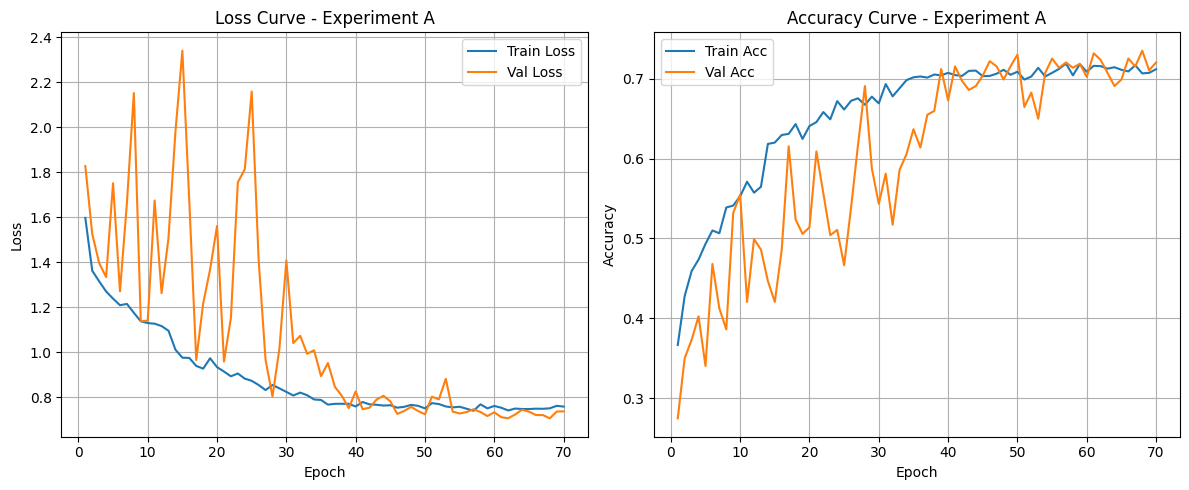

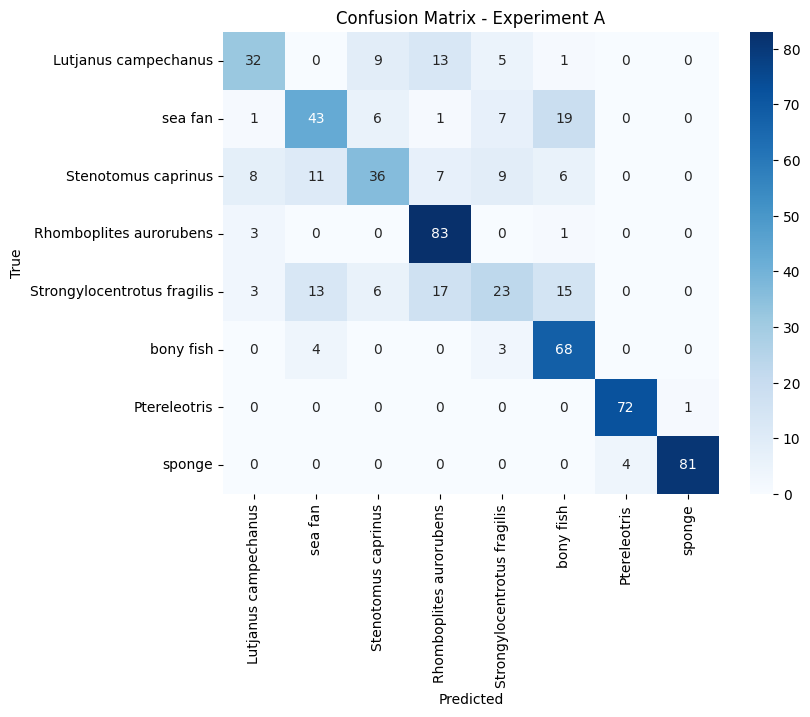

Per-class metrics - Experiment A:
Lutjanus campechanus: Precision=0.681, Recall=0.533, F1=0.598
sea fan: Precision=0.606, Recall=0.558, F1=0.581
Stenotomus caprinus: Precision=0.632, Recall=0.468, F1=0.537
Rhomboplites aurorubens: Precision=0.686, Recall=0.954, F1=0.798
Strongylocentrotus fragilis: Precision=0.489, Recall=0.299, F1=0.371
bony fish: Precision=0.618, Recall=0.907, F1=0.735
Ptereleotris: Precision=0.947, Recall=0.986, F1=0.966
sponge: Precision=0.988, Recall=0.953, F1=0.970

Macro F1 (Experiment A): 0.695
Overall Accuracy (Experiment A): 0.717


In [ ]:
visualize_experiment_full(lossA, vlossA, accA, vaccA, reportA, macro_f1A, accuracyA, cmA, class_names=id_classes,title_suffix='Experiment A')


Suggested OOD threshold for TPR=95%: 0.345
FPR at this threshold: 0.270
AUROC: 0.860


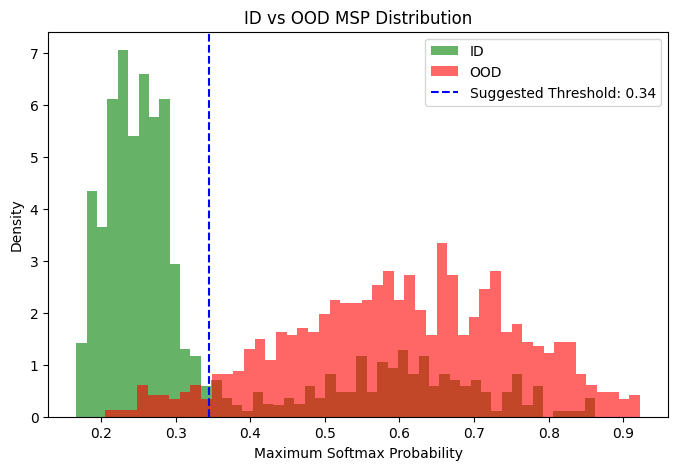


--- Model A OOD Evaluation ---
Macro F1: 0.693
Overall Accuracy: 0.795
Confusion Matrix:
 [[163 448]
 [ 52 968]]
Precision and Recall per class:
Known (ID): Precision=0.758, Recall=0.267
Unknown (OOD): Precision=0.684, Recall=0.949


In [ ]:
# ----------------------------
# Model A OOD Evaluation
# ----------------------------
best_threshA = suggest_ood_threshold(
    model=modelA,
    val_loader=val_loader,
    ood_loader=ood_loader,
    device=DEVICE,
    plot=True,
    temp=5
)

reportA_ood, cmA_ood, macro_f1A_ood, accuracyA_ood = evaluate_ood_detection(
    model=modelA,
    val_loader=val_loader,
    ood_loader=ood_loader,
    threshold=best_threshA,
    temp=5
)

print("\n--- Model A OOD Evaluation ---")
print(f"Macro F1: {macro_f1A_ood:.3f}")
print(f"Overall Accuracy: {accuracyA_ood:.3f}")
print("Confusion Matrix:\n", cmA_ood)
print("Precision and Recall per class:")
for cls_name, metrics in reportA_ood.items():
    if cls_name not in ['accuracy', 'macro avg', 'weighted avg']:
        precision = metrics.get('precision', 0)
        recall = metrics.get('recall', 0)
        print(f"{cls_name}: Precision={precision:.3f}, Recall={recall:.3f}")



## Experiment 2

In [ ]:
lossB, vlossB, accB, vaccB, reportB, macro_f1B, accuracyB, cmB, modelB = run_experiment(
    lr=3e-4,
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=NUM_CLASSES,
    epochs=70,
    threshold=0.7,
    class_names=id_classes
)

Epoch 1/70 | Val Acc=0.296 | Val Loss=1.766
Time=18.24s | ETA=20.98 min
Epoch 2/70 | Val Acc=0.470 | Val Loss=1.334
Time=19.07s | ETA=21.14 min
Epoch 3/70 | Val Acc=0.365 | Val Loss=1.409
Time=18.23s | ETA=20.68 min
Epoch 4/70 | Val Acc=0.463 | Val Loss=1.291
Time=19.01s | ETA=20.50 min
Epoch 5/70 | Val Acc=0.538 | Val Loss=1.191
Time=18.26s | ETA=20.11 min
Epoch 6/70 | Val Acc=0.471 | Val Loss=1.268
Time=19.04s | ETA=19.89 min
Epoch 7/70 | Val Acc=0.475 | Val Loss=1.303
Time=18.17s | ETA=19.50 min
Epoch 8/70 | Val Acc=0.457 | Val Loss=1.376
Time=18.91s | ETA=19.24 min
ReduceLROnPlateau triggered: LR 0.000300 → 0.000150
Epoch 9/70 | Val Acc=0.444 | Val Loss=1.379
Time=18.35s | ETA=18.90 min
Epoch 10/70 | Val Acc=0.563 | Val Loss=1.095
Time=18.83s | ETA=18.61 min
Epoch 11/70 | Val Acc=0.452 | Val Loss=1.406
Time=18.33s | ETA=18.28 min
Epoch 12/70 | Val Acc=0.615 | Val Loss=1.032
Time=18.89s | ETA=17.99 min
Epoch 13/70 | Val Acc=0.640 | Val Loss=1.025
Time=23.25s | ETA=18.02 min
Epoch 14

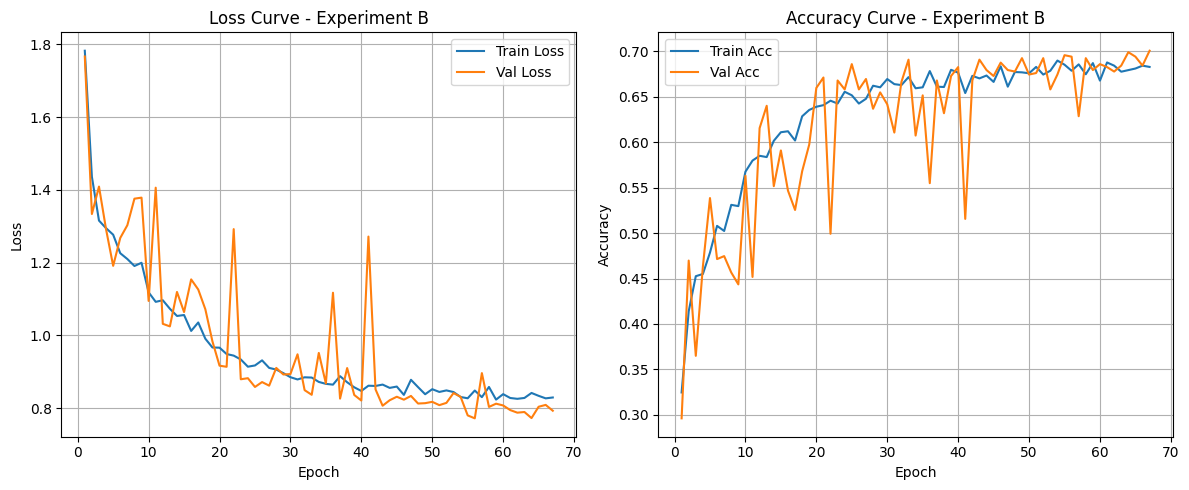

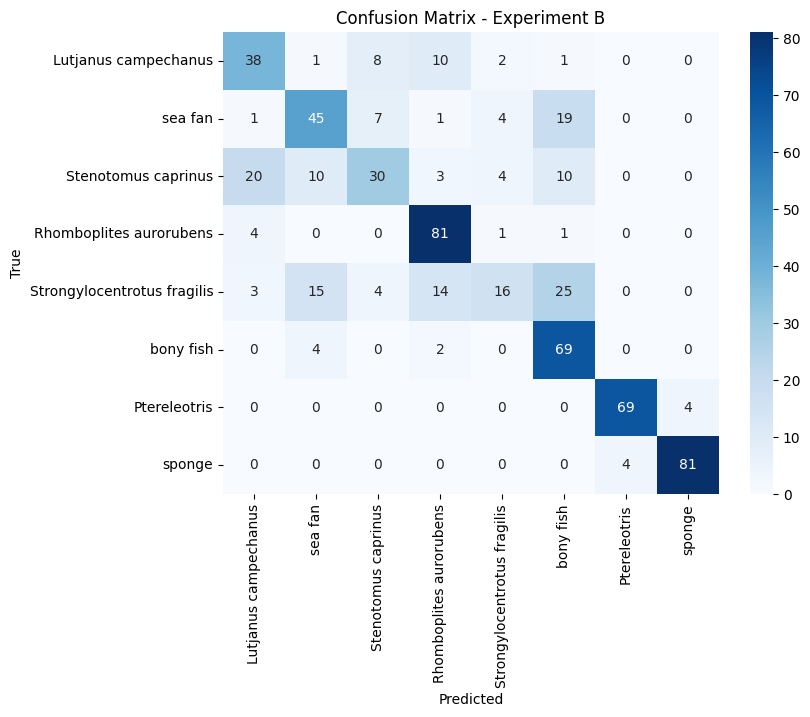

Per-class metrics - Experiment B:
Lutjanus campechanus: Precision=0.576, Recall=0.633, F1=0.603
sea fan: Precision=0.600, Recall=0.584, F1=0.592
Stenotomus caprinus: Precision=0.612, Recall=0.390, F1=0.476
Rhomboplites aurorubens: Precision=0.730, Recall=0.931, F1=0.818
Strongylocentrotus fragilis: Precision=0.593, Recall=0.208, F1=0.308
bony fish: Precision=0.552, Recall=0.920, F1=0.690
Ptereleotris: Precision=0.945, Recall=0.945, F1=0.945
sponge: Precision=0.953, Recall=0.953, F1=0.953

Macro F1 (Experiment B): 0.673
Overall Accuracy (Experiment B): 0.702


In [ ]:
visualize_experiment_full(lossB, vlossB, accB, vaccB, reportB, macro_f1B, accuracyB, cmB,class_names=id_classes,title_suffix='Experiment B')

Suggested OOD threshold for TPR=95%: 0.272
FPR at this threshold: 0.301
AUROC: 0.849


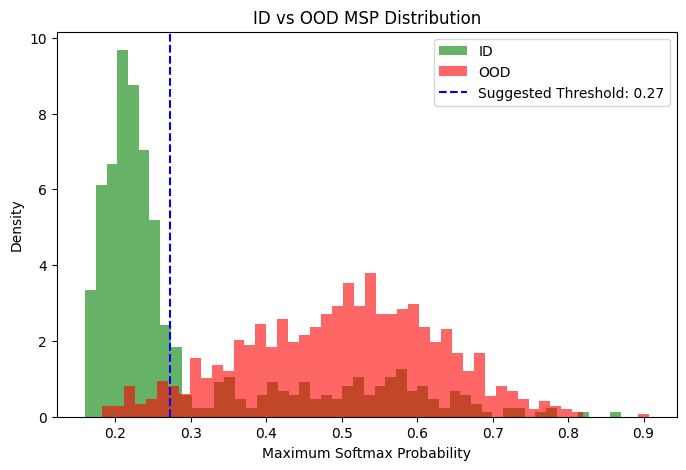


--- Model B OOD Evaluation ---
Macro F1: 0.708
Overall Accuracy: 0.804
Confusion Matrix:
 [[179 432]
 [ 44 976]]
Precision and Recall per class:
Known (ID): Precision=0.803, Recall=0.293
Unknown (OOD): Precision=0.693, Recall=0.957


In [ ]:
# ----------------------------
# Model B OOD Evaluation
# ----------------------------
best_threshB = suggest_ood_threshold(
    model=modelB,
    val_loader=val_loader,
    ood_loader=ood_loader,
    device=DEVICE,
    plot=True,
    target_tpr=0.95,
    temp=5
)

reportB_ood, cmB_ood, macro_f1B_ood, accuracyB_ood = evaluate_ood_detection(
    model=modelB,
    val_loader=val_loader,
    ood_loader=ood_loader,
    threshold=best_threshB,
    temp=5
)

print("\n--- Model B OOD Evaluation ---")
print(f"Macro F1: {macro_f1B_ood:.3f}")
print(f"Overall Accuracy: {accuracyB_ood:.3f}")
print("Confusion Matrix:\n", cmB_ood)
print("Precision and Recall per class:")
for cls_name, metrics in reportB_ood.items():
    if cls_name not in ['accuracy', 'macro avg', 'weighted avg']:
        precision = metrics.get('precision', 0)
        recall = metrics.get('recall', 0)
        print(f"{cls_name}: Precision={precision:.3f}, Recall={recall:.3f}")

# Model B

In [ ]:
import time
import torch
import torch.nn as nn

def train_transfer(model, lr, epochs=8, train_loader=None, val_loader=None):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    total_start = time.time()
    for epoch in range(epochs):
        epoch_start = time.time()

        # Train one epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)

        # Validation
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Time calculation
        elapsed = time.time() - total_start
        avg_epoch_time = elapsed / (epoch + 1)
        remaining_time = avg_epoch_time * (epochs - epoch - 1)

        print(f"Epoch {epoch+1}/{epochs}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}, "
              f"Train Loss={train_loss:.3f}, Val Loss={val_loss:.3f}, "
              f"Elapsed={elapsed/60:.2f} min, ETA={remaining_time/60:.2f} min")

    return train_losses, val_losses, train_accs, val_accs

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import numpy as np

def run_resnet_transfer_experiment(train_loader, val_loader, num_classes, class_names,
                                   epochs_stage1=5, epochs_stage2=5, epochs_stage3=5,
                                   lr_stage1=1e-3, lr_stage2=3e-4, lr_stage3=1e-5,
                                   device='cuda'):

    DEVICE = device
    metrics = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'stage': []}
    stage_reports = {}   # to store per-stage metrics
    models_per_stage = {}  # to store trained models

    # -------------------------------
    # Build ResNet50 with new classification head
    # -------------------------------
    def build_resnet50(num_classes):
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model

    model = build_resnet50(num_classes).to(DEVICE)

    # -------------------------------
    # Stage 1: Feature Extraction
    # -------------------------------
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    tr_l1, v_l1, tr_a1, v_a1 = train_transfer(model, lr=lr_stage1, epochs=epochs_stage1,
                                               train_loader=train_loader, val_loader=val_loader)
    metrics['train_loss'].extend(tr_l1)
    metrics['val_loss'].extend(v_l1)
    metrics['train_acc'].extend(tr_a1)
    metrics['val_acc'].extend(v_a1)
    metrics['stage'].extend(['Feature Extraction'] * len(tr_l1))

    stage_reports['Feature Extraction'] = evaluate_stage(model, val_loader, num_classes, class_names, DEVICE)
    models_per_stage['Feature Extraction'] = model  # save the model

    # -------------------------------
    # Stage 2: Partial Fine-tuning
    # -------------------------------
    for param in model.layer4.parameters():
        param.requires_grad = True

    tr_l2, v_l2, tr_a2, v_a2 = train_transfer(model, lr=lr_stage2, epochs=epochs_stage2,
                                               train_loader=train_loader, val_loader=val_loader)
    metrics['train_loss'].extend(tr_l2)
    metrics['val_loss'].extend(v_l2)
    metrics['train_acc'].extend(tr_a2)
    metrics['val_acc'].extend(v_a2)
    metrics['stage'].extend(['Partial Fine-tune'] * len(tr_l2))

    stage_reports['Partial Fine-tune'] = evaluate_stage(model, val_loader, num_classes, class_names, DEVICE)
    models_per_stage['Partial Fine-tune'] = model  # save the model

    # -------------------------------
    # Stage 3: Full Fine-tuning with frozen BN
    # -------------------------------
    def freeze_bn(m):
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            for param in m.parameters():
                param.requires_grad = False

    model.apply(freeze_bn)

    for param in model.parameters():
        if not isinstance(param, nn.BatchNorm2d):
            param.requires_grad = True

    tr_l3, v_l3, tr_a3, v_a3 = train_transfer(model, lr=lr_stage3, epochs=epochs_stage3,
                                               train_loader=train_loader, val_loader=val_loader)
    metrics['train_loss'].extend(tr_l3)
    metrics['val_loss'].extend(v_l3)
    metrics['train_acc'].extend(tr_a3)
    metrics['val_acc'].extend(v_a3)
    metrics['stage'].extend(['Full Fine-tune'] * len(tr_l3))

    stage_reports['Full Fine-tune'] = evaluate_stage(model, val_loader, num_classes, class_names, DEVICE)
    models_per_stage['Full Fine-tune'] = model  # save the model

    # -------------------------------
    # Return metrics, stage reports, and the 3 trained models
    # -------------------------------
    return metrics, stage_reports, models_per_stage


# -------------------------------
# Evaluation function per stage (ID only)
# -------------------------------
def evaluate_stage(model, val_loader, num_classes, class_names, device='cuda'):
    DEVICE = device
    y_true, y_pred = [], []

    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            pred_idx = torch.argmax(outputs, dim=1)
            y_pred.extend(pred_idx.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Find which labels are actually present in this batch
    unique_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))

    # Only include target names for labels that are present
    present_class_names = [class_names[i] for i in unique_labels]

    # Classification report
    report = classification_report(
        y_true, y_pred,
        labels=unique_labels,
        target_names=present_class_names,
        digits=3,
        output_dict=True,
        zero_division=0  # avoids crashes for missing classes
    )

    # Macro F1 and accuracy over all present labels
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

    return report, macro_f1, accuracy, cm

In [ ]:
def get_stage_metrics(metrics, stage_name):
    indices = [i for i, s in enumerate(metrics['stage']) if s == stage_name]
    tr_l = [metrics['train_loss'][i] for i in indices]
    v_l = [metrics['val_loss'][i] for i in indices]
    tr_a = [metrics['train_acc'][i] for i in indices]
    v_a = [metrics['val_acc'][i] for i in indices]
    return tr_l, v_l, tr_a, v_a

Epoch 1/5: Train Acc=0.595, Val Acc=0.679, Train Loss=1.129, Val Loss=0.844, Elapsed=0.40 min, ETA=1.60 min
Epoch 2/5: Train Acc=0.729, Val Acc=0.766, Train Loss=0.732, Val Loss=0.644, Elapsed=0.77 min, ETA=1.16 min
Epoch 3/5: Train Acc=0.740, Val Acc=0.782, Train Loss=0.672, Val Loss=0.623, Elapsed=1.15 min, ETA=0.77 min
Epoch 4/5: Train Acc=0.765, Val Acc=0.782, Train Loss=0.622, Val Loss=0.581, Elapsed=1.52 min, ETA=0.38 min
Epoch 5/5: Train Acc=0.772, Val Acc=0.795, Train Loss=0.602, Val Loss=0.551, Elapsed=1.92 min, ETA=0.00 min
Epoch 1/15: Train Acc=0.799, Val Acc=0.815, Train Loss=0.547, Val Loss=0.492, Elapsed=0.43 min, ETA=5.98 min
Epoch 2/15: Train Acc=0.835, Val Acc=0.828, Train Loss=0.451, Val Loss=0.471, Elapsed=0.86 min, ETA=5.58 min
Epoch 3/15: Train Acc=0.860, Val Acc=0.817, Train Loss=0.369, Val Loss=0.457, Elapsed=1.29 min, ETA=5.15 min
Epoch 4/15: Train Acc=0.886, Val Acc=0.838, Train Loss=0.312, Val Loss=0.465, Elapsed=1.71 min, ETA=4.71 min
Epoch 5/15: Train Acc=0.

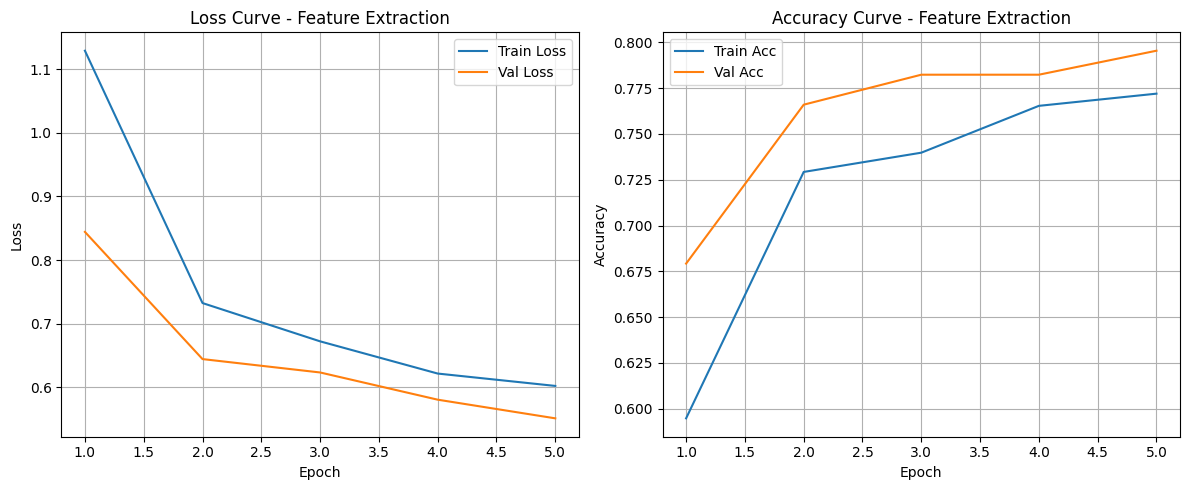

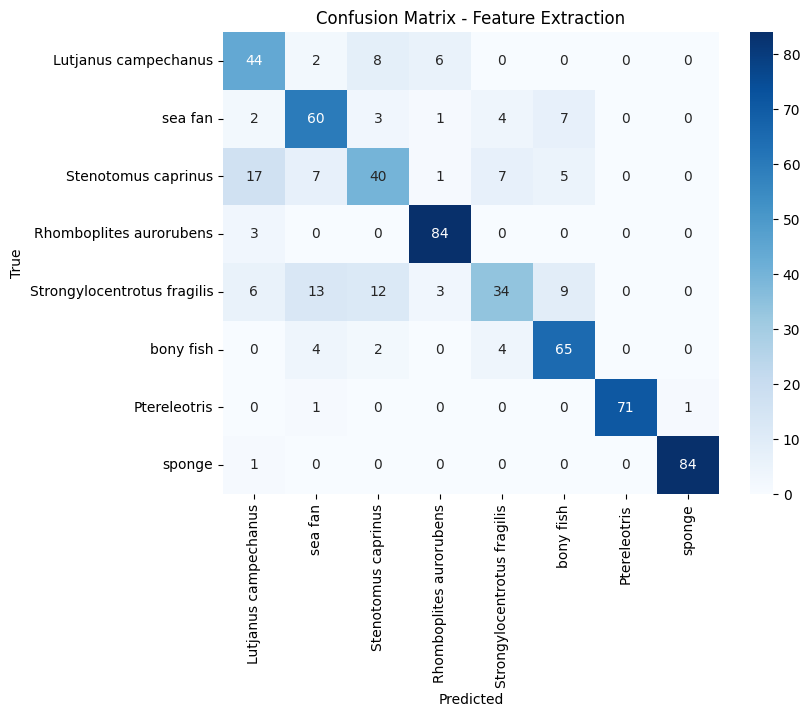

Per-class metrics - Feature Extraction:
Lutjanus campechanus: Precision=0.603, Recall=0.733, F1=0.662
sea fan: Precision=0.690, Recall=0.779, F1=0.732
Stenotomus caprinus: Precision=0.615, Recall=0.519, F1=0.563
Rhomboplites aurorubens: Precision=0.884, Recall=0.966, F1=0.923
Strongylocentrotus fragilis: Precision=0.694, Recall=0.442, F1=0.540
bony fish: Precision=0.756, Recall=0.867, F1=0.807
Ptereleotris: Precision=1.000, Recall=0.973, F1=0.986
sponge: Precision=0.988, Recall=0.988, F1=0.988

Macro F1 (Feature Extraction): 0.775
Overall Accuracy (Feature Extraction): 0.789


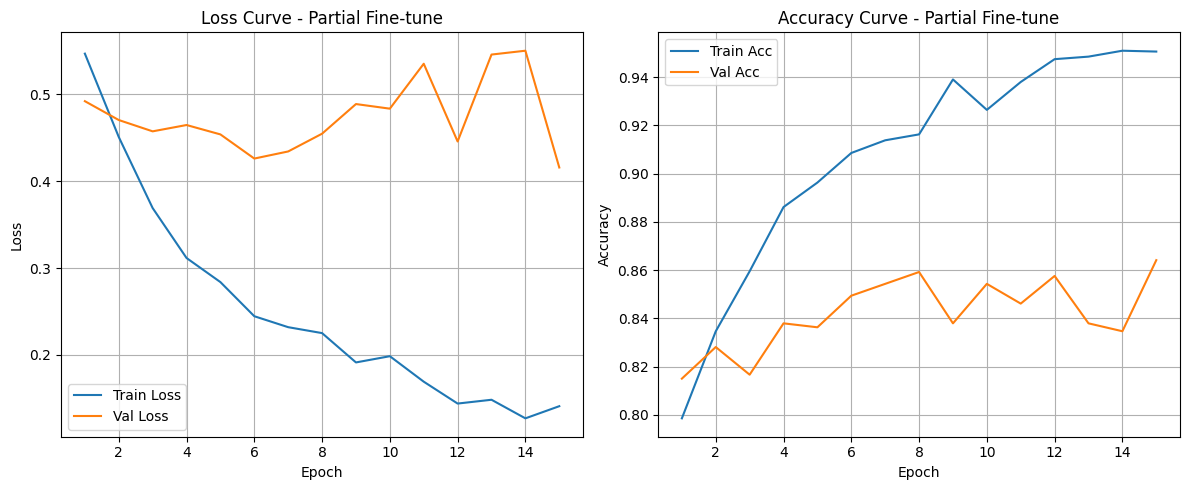

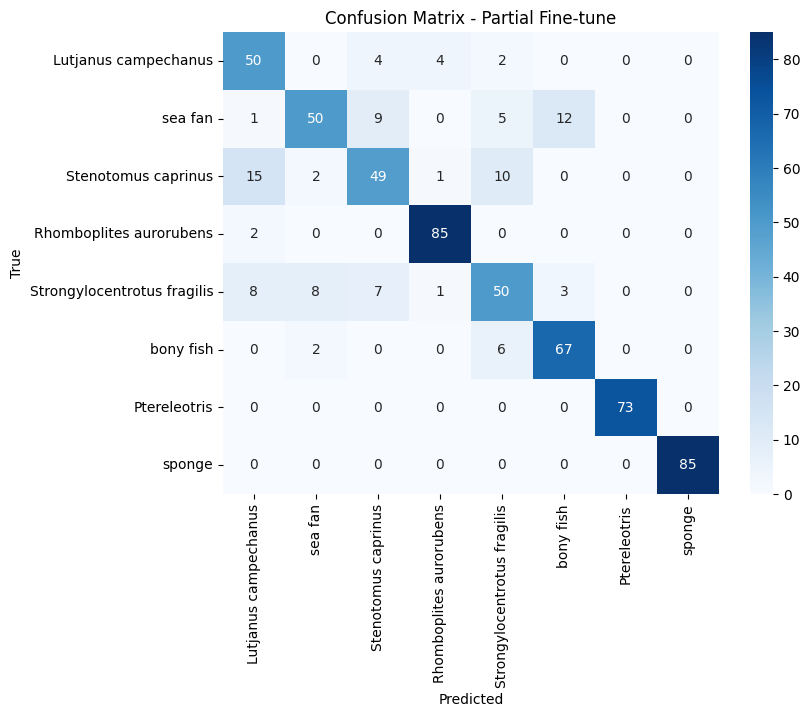

Per-class metrics - Partial Fine-tune:
Lutjanus campechanus: Precision=0.658, Recall=0.833, F1=0.735
sea fan: Precision=0.806, Recall=0.649, F1=0.719
Stenotomus caprinus: Precision=0.710, Recall=0.636, F1=0.671
Rhomboplites aurorubens: Precision=0.934, Recall=0.977, F1=0.955
Strongylocentrotus fragilis: Precision=0.685, Recall=0.649, F1=0.667
bony fish: Precision=0.817, Recall=0.893, F1=0.854
Ptereleotris: Precision=1.000, Recall=1.000, F1=1.000
sponge: Precision=1.000, Recall=1.000, F1=1.000

Macro F1 (Partial Fine-tune): 0.825
Overall Accuracy (Partial Fine-tune): 0.833


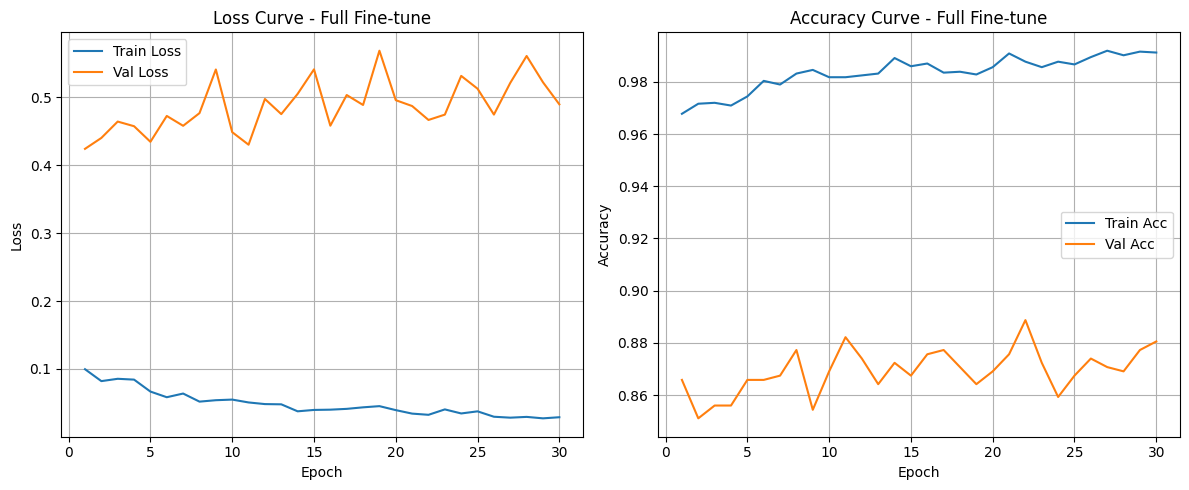

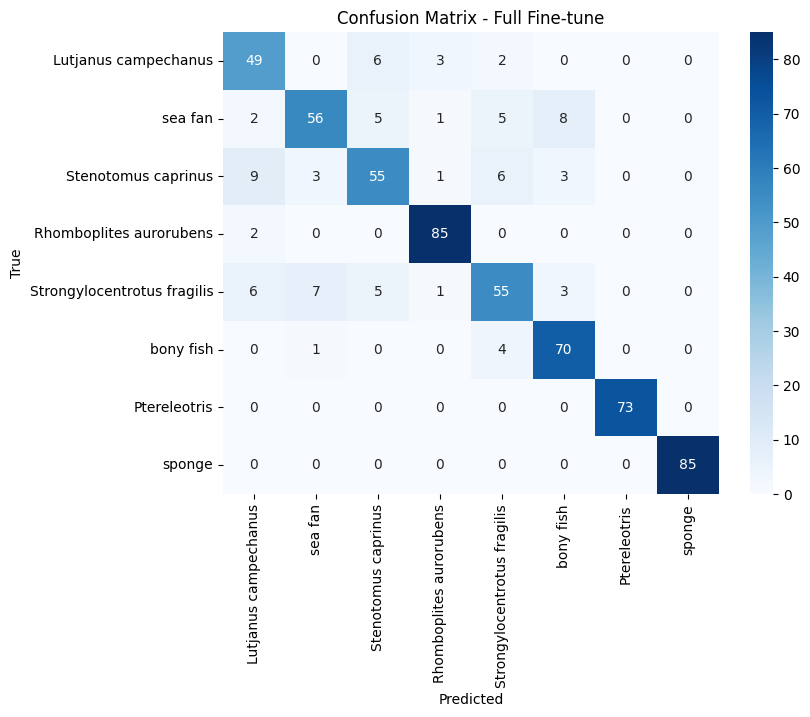

Per-class metrics - Full Fine-tune:
Lutjanus campechanus: Precision=0.721, Recall=0.817, F1=0.766
sea fan: Precision=0.836, Recall=0.727, F1=0.778
Stenotomus caprinus: Precision=0.775, Recall=0.714, F1=0.743
Rhomboplites aurorubens: Precision=0.934, Recall=0.977, F1=0.955
Strongylocentrotus fragilis: Precision=0.764, Recall=0.714, F1=0.738
bony fish: Precision=0.833, Recall=0.933, F1=0.881
Ptereleotris: Precision=1.000, Recall=1.000, F1=1.000
sponge: Precision=1.000, Recall=1.000, F1=1.000

Macro F1 (Full Fine-tune): 0.858
Overall Accuracy (Full Fine-tune): 0.864


In [ ]:
metrics, stage_reports,models_per_stage = run_resnet_transfer_experiment(
    train_loader, val_loader, NUM_CLASSES, id_classes,epochs_stage1=5, epochs_stage2=15, epochs_stage3=30,
)

# Visualize each stage
for stage_name in ['Feature Extraction', 'Partial Fine-tune', 'Full Fine-tune']:
    tr_l, v_l, tr_a, v_a = get_stage_metrics(metrics, stage_name)
    report, macro_f1, acc, cm = stage_reports[stage_name]
    visualize_experiment_full(tr_l, v_l, tr_a, v_a, report, macro_f1, acc, cm,
                              class_names=id_classes,
                              title_suffix=stage_name)

Suggested OOD threshold for TPR=95%: 0.303
FPR at this threshold: 0.882
AUROC: 0.517


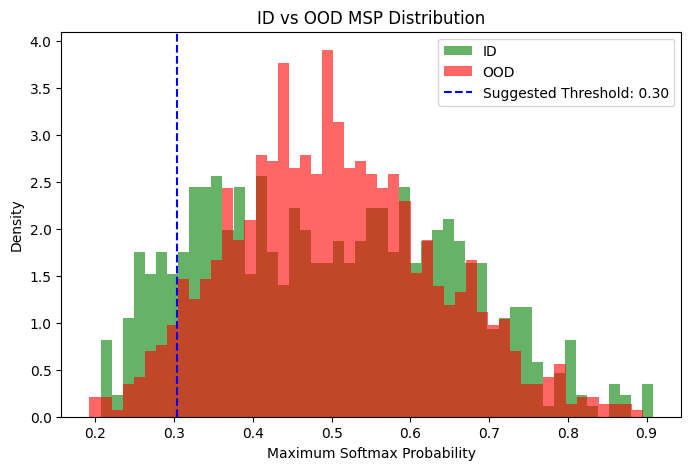

--- OOD Evaluation: Feature Extraction ---
Accuracy: 0.936, Macro F1: 0.918
Precision and Recall per class:
Known (ID): Precision=0.912, Recall=0.866
Unknown (OOD): Precision=0.922, Recall=0.950


Suggested OOD threshold for TPR=95%: 0.299
FPR at this threshold: 0.871
AUROC: 0.516


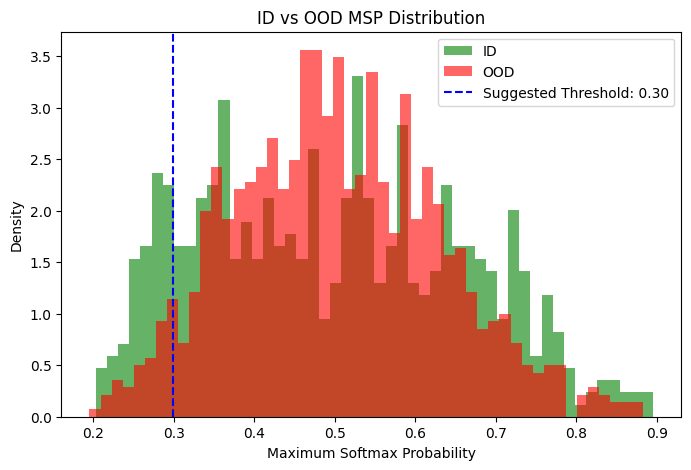

--- OOD Evaluation: Partial Fine-tune ---
Accuracy: 0.941, Macro F1: 0.925
Precision and Recall per class:
Known (ID): Precision=0.915, Recall=0.882
Unknown (OOD): Precision=0.931, Recall=0.951


Suggested OOD threshold for TPR=95%: 0.305
FPR at this threshold: 0.854
AUROC: 0.512


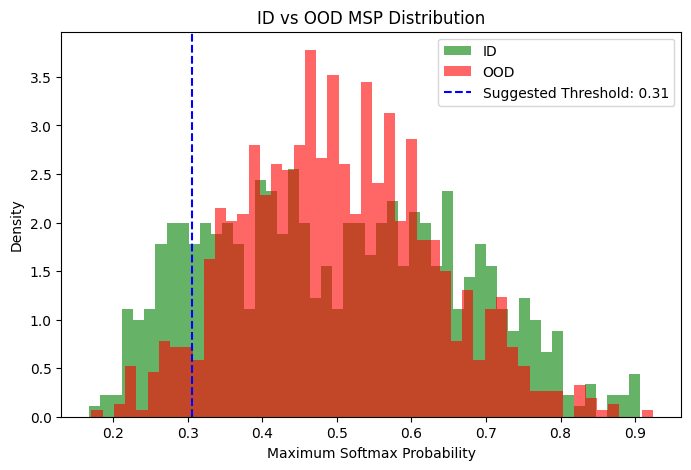

--- OOD Evaluation: Full Fine-tune ---
Accuracy: 0.940, Macro F1: 0.924
Precision and Recall per class:
Known (ID): Precision=0.915, Recall=0.879
Unknown (OOD): Precision=0.929, Recall=0.951




In [ ]:
ood_reports = {}

for stage_name in ['Feature Extraction', 'Partial Fine-tune', 'Full Fine-tune']:
    model = models_per_stage[stage_name]

    # Suggest threshold for OOD detection
    best_thresh = suggest_ood_threshold(
        model=model,
        val_loader=val_loader,
        ood_loader=ood_loader,
        device=DEVICE,
        plot=True,
        target_tpr=0.95,  # keep 95% of ID correctly detected
        temp=8
    )

    # Evaluate OOD detection
    report, cm, macro_f1, acc = evaluate_ood_detection(
        model=model,
        val_loader=val_loader,
        ood_loader=ood_loader,
        threshold=best_thresh,
        temp=8
    )

    # Store results
    ood_reports[stage_name] = {
        'report': report,
        'macro_f1': macro_f1,
        'accuracy': acc,
        'confusion_matrix': cm
    }

    # Print summary
    print(f"--- OOD Evaluation: {stage_name} ---")
    print(f"Accuracy: {acc:.3f}, Macro F1: {macro_f1:.3f}")

    # Print per-class precision and recall
    print("Precision and Recall per class:")
    for cls_name, metrics in report.items():
        if cls_name not in ['accuracy', 'macro avg', 'weighted avg']:
            precision = metrics.get('precision', 0)
            recall = metrics.get('recall', 0)
            print(f"{cls_name}: Precision={precision:.3f}, Recall={recall:.3f}")
    print("\n")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/my_models/'
os.makedirs(save_path, exist_ok=True)

# Example for PyTorch:
import torch
torch.save(modelA.state_dict(), '/content/drive/MyDrive/my_models/experiment_a.pth')
torch.save(modelB.state_dict(), '/content/drive/MyDrive/my_models/experiment_b.pth')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
for i, name in enumerate(['Feature Extraction', 'Partial Fine-tune', 'Full Fine-tune']):
    model=models_per_stage[name]
    torch.save(model.state_dict(), f"/content/drive/MyDrive/my_models/model_stage{i}.pth")

In [ ]:
models_per_stage

{'Feature Extraction': ResNet(
   (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
   (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
   (layer1): Sequential(
     (0): Bottleneck(
       (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
       (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (downsample): Sequential(
         (0): Conv2d(64

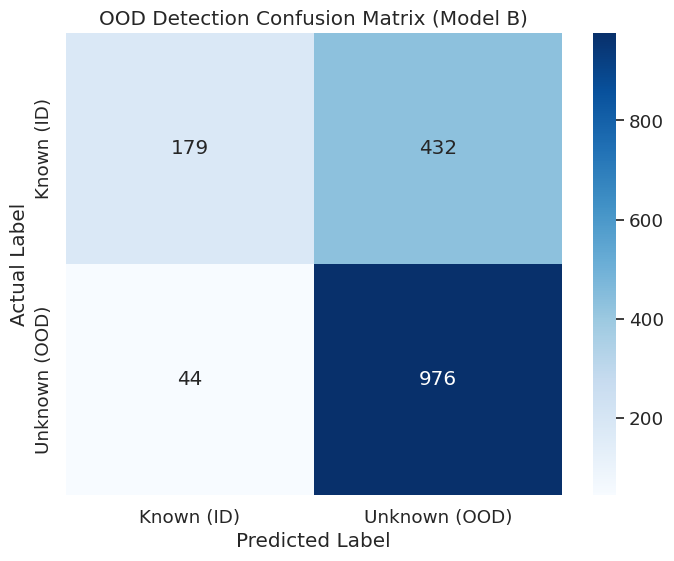

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Data from your Model B OOD Evaluation
# [[TN, FP], [FN, TP]] -> [[Known_Correct, Known_as_OOD], [OOD_as_Known, OOD_Correct]]
cm = np.array([[179, 432],
               [44, 976]])

plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
# Creating the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Known (ID)', 'Unknown (OOD)'],
            yticklabels=['Known (ID)', 'Unknown (OOD)'])

plt.title('OOD Detection Confusion Matrix (Model B)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('modelB_ood_cm.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
!pip freeze > requirements.txt
